# Exploratory Data Analysis

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [3]:
df_train = pd.read_csv('data/train.csv')
df_test = pd.read_csv('data/test.csv')
df_original = pd.read_csv('data/Rainfall.csv')

In [4]:
df_train.head()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0


In [5]:
train = df_train.copy()
train.drop(['id', 'day'], axis=1, inplace=True)
train.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0


- 2190 observations
- we removed columns 'id' and 'day' from the data as they are not useful for the model
- we will use the 'rainfall' column as the target variable

In [6]:
X_train = train.drop('rainfall', axis=1)
Y_train = train['rainfall']
target = 'rainfall'

Prepare data from original dataset that was the source of data for model which generated data for our competition

In [7]:
df_original.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,2,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,3,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,4,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,5,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7


In [8]:
df_original.columns= df_original.columns.str.strip()
original = df_original.copy()
original.drop(['day'], axis=1, inplace=True)
original['rainfall'] = original['rainfall'].map({'no': 0, 'yes': 1})

In [9]:
original.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1025.9,19.9,18.3,16.8,13.1,72,49,1,9.3,80.0,26.3
1,1022.0,21.7,18.9,17.2,15.6,81,83,1,0.6,50.0,15.3
2,1019.7,20.3,19.3,18.0,18.4,95,91,1,0.0,40.0,14.2
3,1018.9,22.3,20.6,19.1,18.8,90,88,1,1.0,50.0,16.9
4,1015.9,21.3,20.7,20.2,19.9,95,81,1,0.0,40.0,13.7


In [10]:
X_original = original.drop('rainfall', axis=1)
Y_original = original['rainfall']

Just like for train dataset we can skip id and day column

In [11]:
df_test.head()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
0,2190,1,1019.5,17.5,15.8,12.7,14.9,96.0,99.0,0.0,50.0,24.3
1,2191,2,1016.5,17.5,16.5,15.8,15.1,97.0,99.0,0.0,50.0,35.3
2,2192,3,1023.9,11.2,10.4,9.4,8.9,86.0,96.0,0.0,40.0,16.9
3,2193,4,1022.9,20.6,17.3,15.2,9.5,75.0,45.0,7.1,20.0,50.6
4,2194,5,1022.2,16.1,13.8,6.4,4.3,68.0,49.0,9.2,20.0,19.4


In [12]:
test = df_test.copy()
test.drop(['id', 'day'], axis=1, inplace=True)
test.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
0,1019.5,17.5,15.8,12.7,14.9,96.0,99.0,0.0,50.0,24.3
1,1016.5,17.5,16.5,15.8,15.1,97.0,99.0,0.0,50.0,35.3
2,1023.9,11.2,10.4,9.4,8.9,86.0,96.0,0.0,40.0,16.9
3,1022.9,20.6,17.3,15.2,9.5,75.0,45.0,7.1,20.0,50.6
4,1022.2,16.1,13.8,6.4,4.3,68.0,49.0,9.2,20.0,19.4


# Info about datset

In [13]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2190 entries, 0 to 2189
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   pressure       2190 non-null   float64
 1   maxtemp        2190 non-null   float64
 2   temparature    2190 non-null   float64
 3   mintemp        2190 non-null   float64
 4   dewpoint       2190 non-null   float64
 5   humidity       2190 non-null   float64
 6   cloud          2190 non-null   float64
 7   sunshine       2190 non-null   float64
 8   winddirection  2190 non-null   float64
 9   windspeed      2190 non-null   float64
 10  rainfall       2190 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 188.3 KB


- no missing values
- only numerical columns (target is int, others float)
- wind direction may be categorical

In [14]:
X_train.describe()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
count,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000
mean,1013.602146,26.365799,23.953059,22.170091,20.454566,82.036530,75.721918,3.744429,104.863151,21.804703
std,5.655366,5.654330,5.222410,5.059120,5.288406,7.800654,18.026498,3.626327,80.002416,9.898659
min,999.000000,10.400000,7.400000,4.000000,-0.300000,39.000000,2.000000,0.000000,10.000000,4.400000
25%,1008.600000,21.300000,19.300000,17.700000,16.800000,77.000000,69.000000,0.400000,40.000000,14.125000
50%,1013.000000,27.800000,25.500000,23.850000,22.150000,82.000000,83.000000,2.400000,70.000000,20.500000
75%,1017.775000,31.200000,28.400000,26.400000,25.000000,88.000000,88.000000,6.800000,200.000000,27.900000
max,1034.600000,36.000000,31.500000,29.800000,26.700000,98.000000,100.000000,12.100000,300.000000,59.500000


In [15]:
X_original.describe()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,365.000000,365.000000
mean,1013.742623,26.191257,23.747268,21.894536,19.989071,80.177596,71.128415,4.419399,101.506849,21.536986
std,6.414776,5.978343,5.632813,5.594153,5.997021,10.062470,21.798012,3.934398,81.723724,10.069712
min,998.500000,7.100000,4.900000,3.100000,-0.400000,36.000000,0.000000,0.000000,10.000000,4.400000
25%,1008.500000,21.200000,18.825000,17.125000,16.125000,75.000000,58.000000,0.500000,40.000000,13.700000
50%,1013.000000,27.750000,25.450000,23.700000,21.950000,80.500000,80.000000,3.500000,70.000000,20.500000
75%,1018.100000,31.200000,28.600000,26.575000,25.000000,87.000000,88.000000,8.200000,190.000000,27.900000
max,1034.600000,36.300000,32.400000,30.000000,26.700000,98.000000,100.000000,12.100000,350.000000,59.500000


In [16]:
len(X_train['winddirection'].unique())

35

Wind direction column has only 35 unique values so we should think about it as categorical column

### Info about target

In [17]:
train['rainfall'].describe()

count    2190.000000
mean        0.753425
std         0.431116
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: rainfall, dtype: float64

In [18]:
train['rainfall'].value_counts()

rainfall
1    1650
0     540
Name: count, dtype: int64

In [19]:
original['rainfall'].value_counts()

rainfall
1    249
0    117
Name: count, dtype: int64

Target for training dataset if imbalanced - there are 3 times more ones than zeros. Original dataset is less imbalanced then training. For imbalanced data, it's better to avoid using accuracy and instead rely on metrics such as precision, recall and F1-score.

## Correlation

<Axes: >

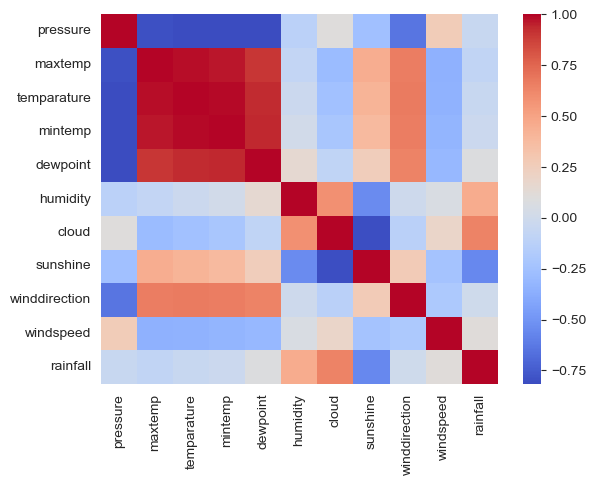

In [20]:
corr = train.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm')

- high correlation gives us big candidates for feature selection: 'maxtemp', 'mintemp', 'temperature' , 'dewpoint' (reasonable to leave only one of them - probably 'temperature' or 'dewpoint')

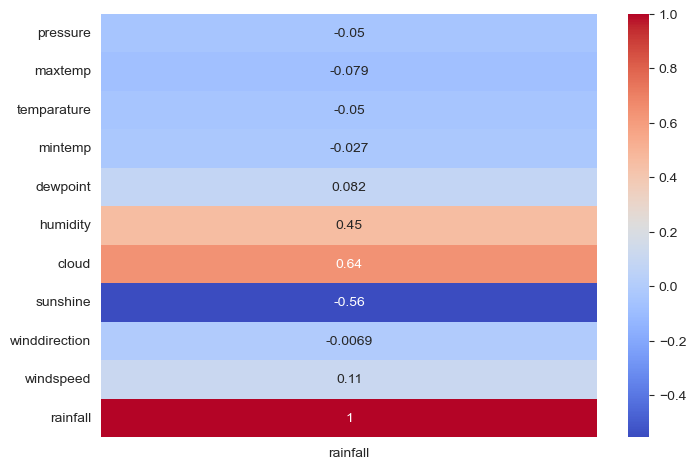

In [21]:
corr_target = train.corr()[['rainfall']]

plt.figure(figsize=(8, len(corr_target)*0.5))
sns.heatmap(corr_target, annot=True, cmap='coolwarm')
# plt.title('Correlation with Target')
plt.show()

- key target predictors are cloud, sunshine and humidity
- pressure and wind speed are the worst predictors

#### Importance of variables - model

In [22]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, Y_train)

importances = model.feature_importances_
feature_importance = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances})
feature_importance = feature_importance.sort_values(by = 'Importance', ascending=False)
print(feature_importance)

         Feature  Importance
6          cloud    0.469018
7       sunshine    0.082561
9      windspeed    0.074572
4       dewpoint    0.066069
0       pressure    0.060101
5       humidity    0.059160
1        maxtemp    0.057619
3        mintemp    0.051024
8  winddirection    0.040841
2    temparature    0.039035


We got more information about importance of variables, so we can have more information about which variables we can maybe remove.

## Feature analysis

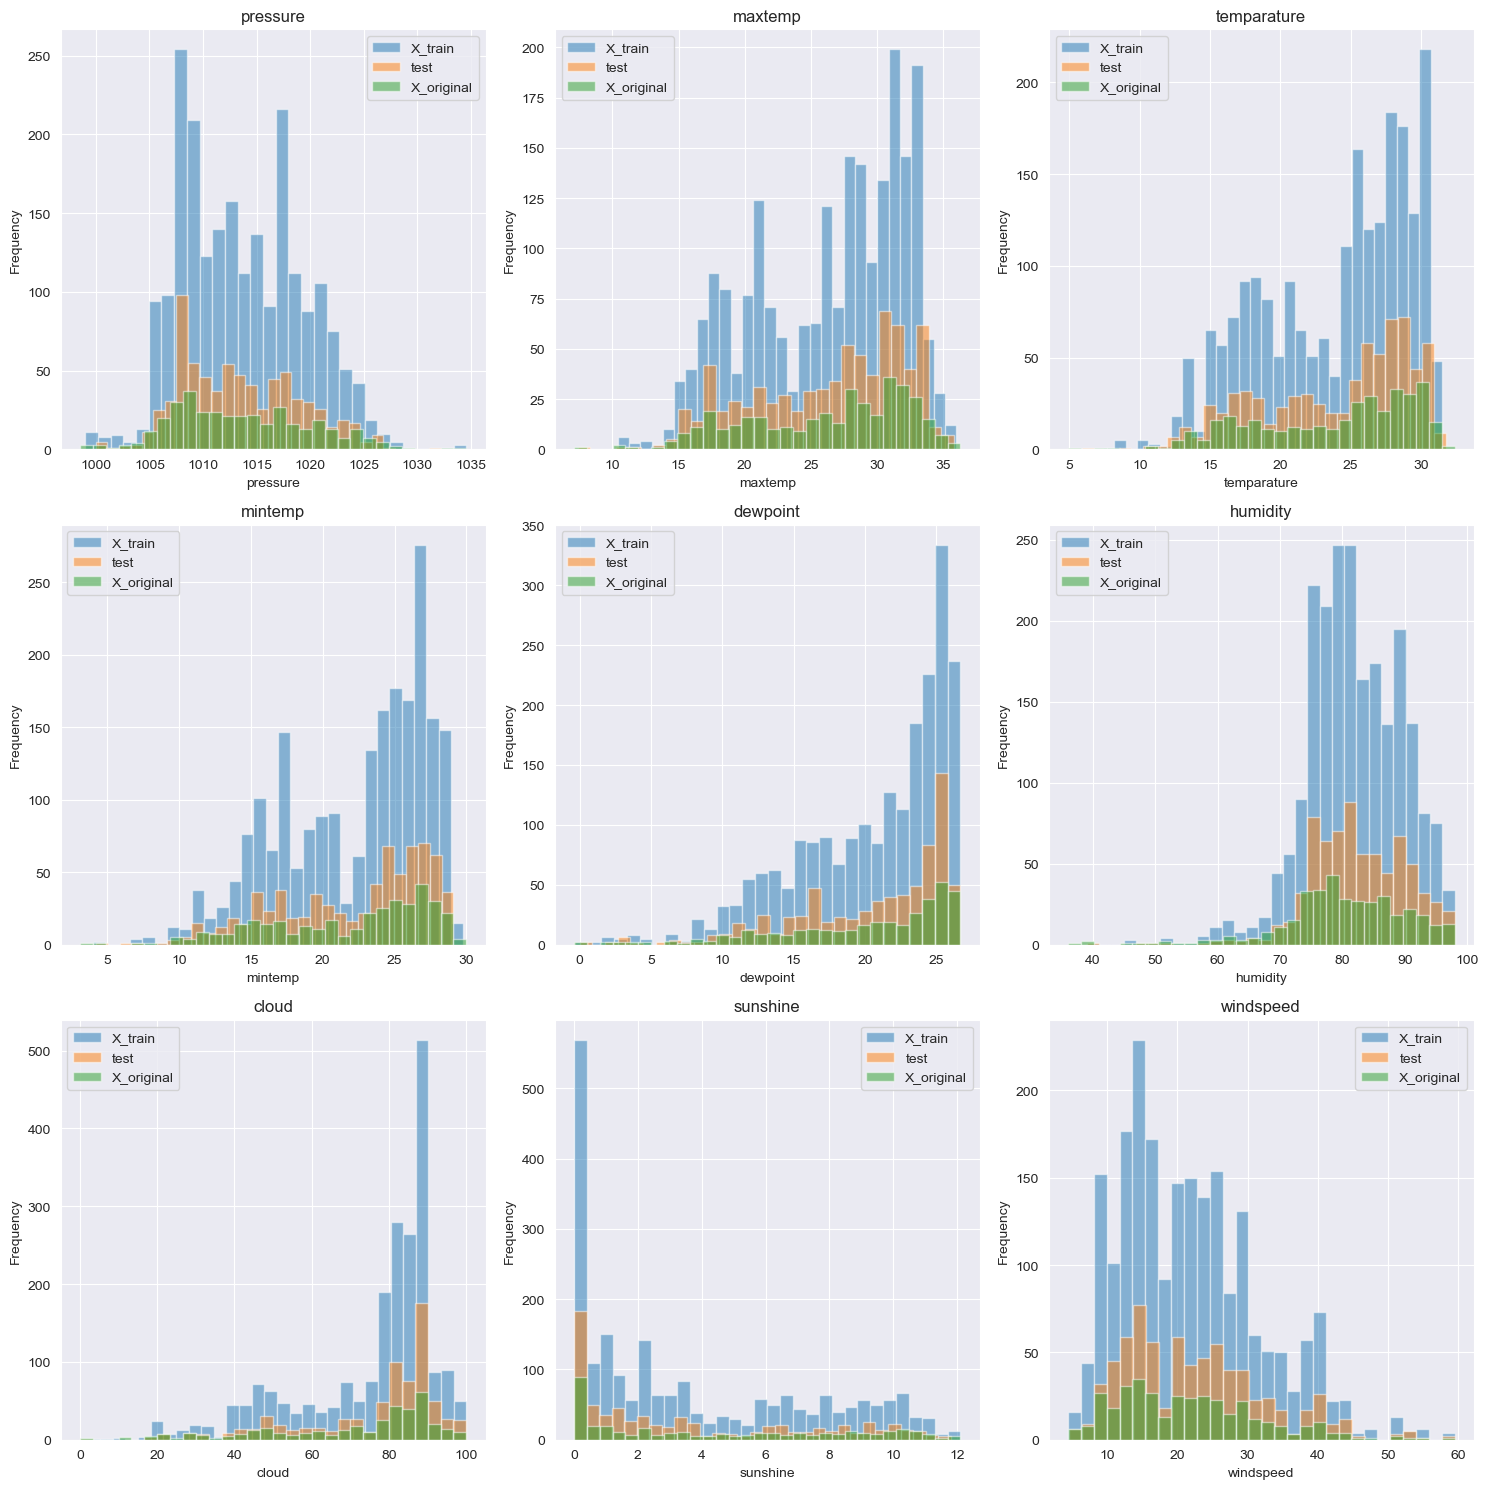

In [23]:
cols_to_plot = [col for col in X_train.columns if col != 'winddirection']

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

for idx, col in enumerate(cols_to_plot):
    ax = axes[idx]
    ax.hist(X_train[col], bins=30, alpha=0.5, label='X_train')
    ax.hist(test[col], bins=30, alpha=0.5, label='test')
    ax.hist(X_original[col], bins=30, alpha=0.5, label='X_original')
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.show()

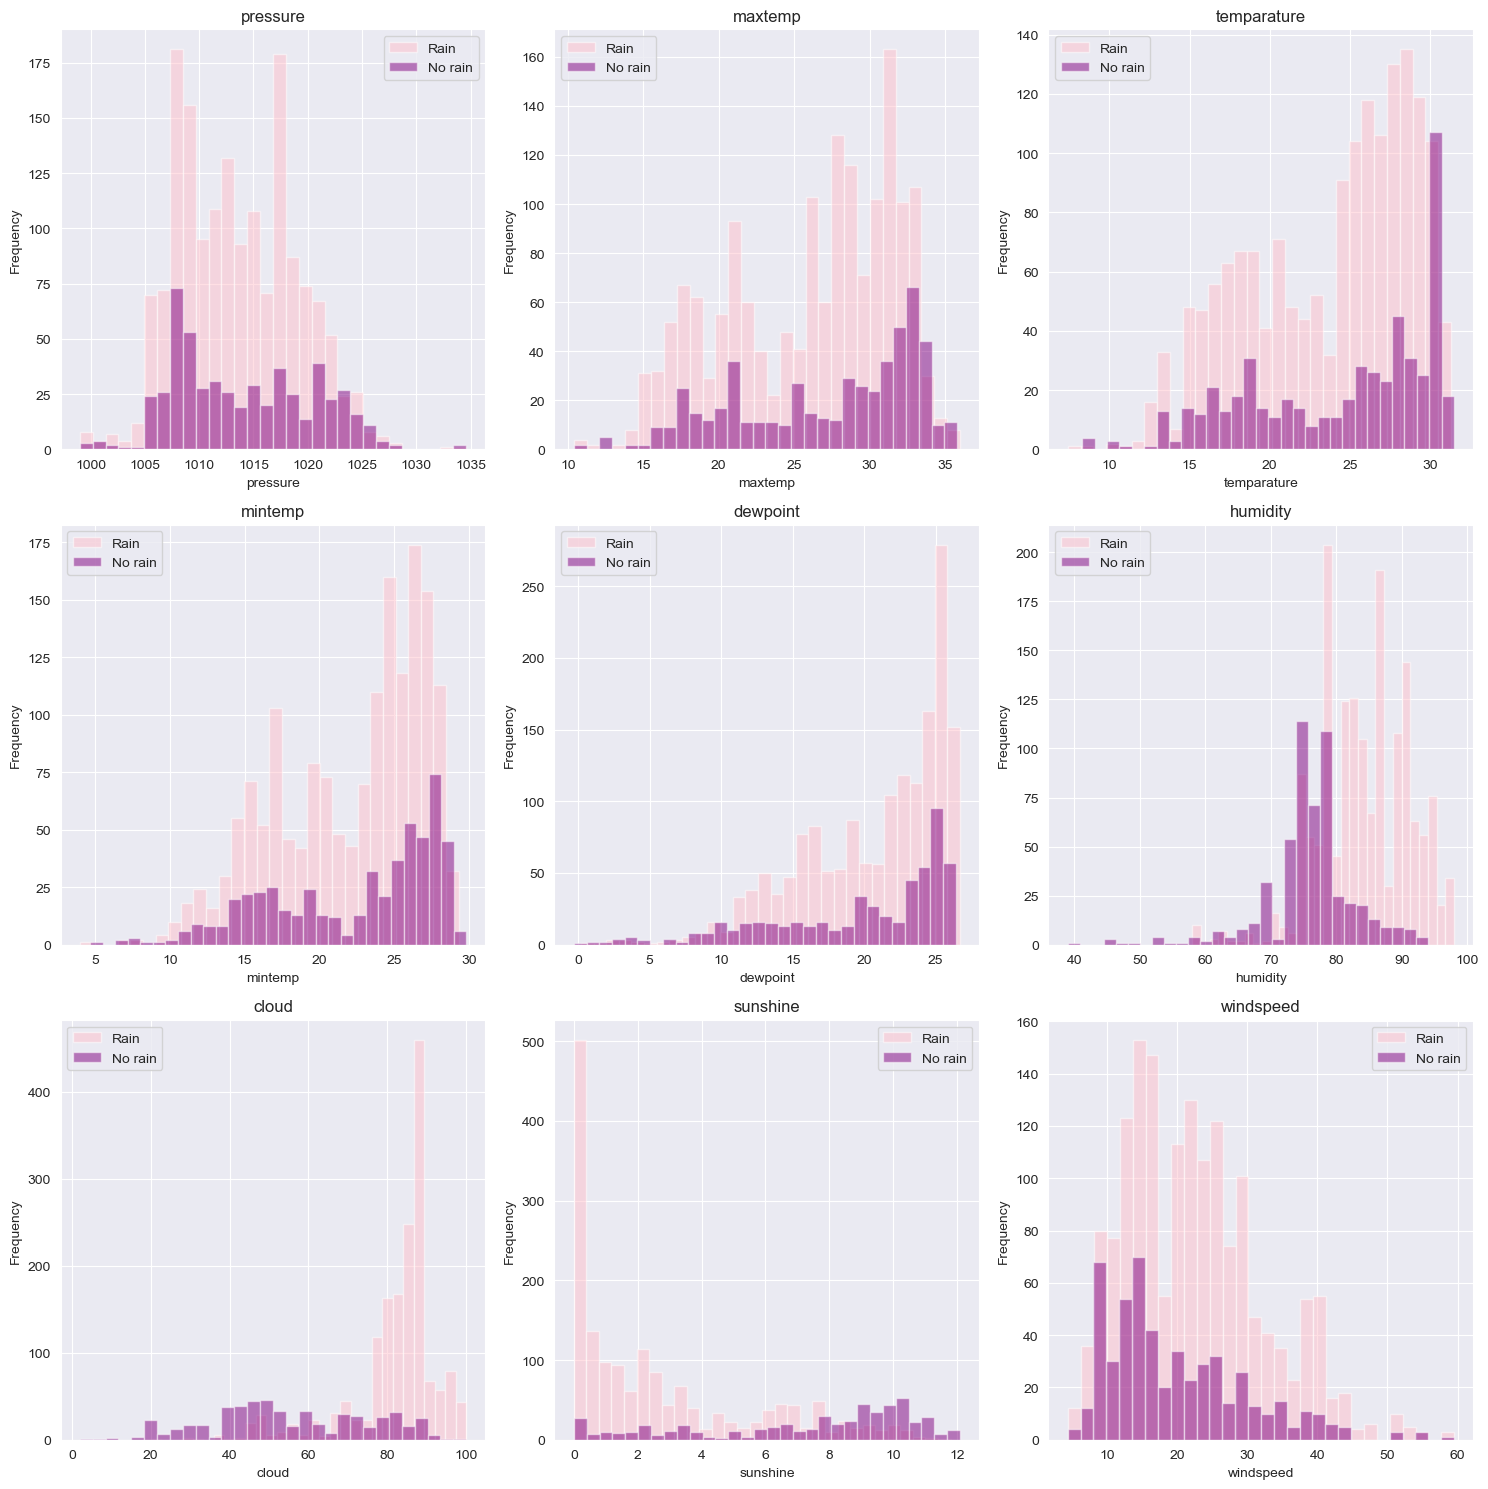

In [28]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

for idx, col in enumerate(cols_to_plot):
    ax = axes[idx]
    ax.hist(train.loc[train['rainfall'] == 1, col], bins=30, alpha=0.5, label='Rain', color='pink')
    ax.hist(train.loc[train['rainfall'] == 0, col], bins=30, alpha=0.5, label='No rain', color='purple')
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.show()

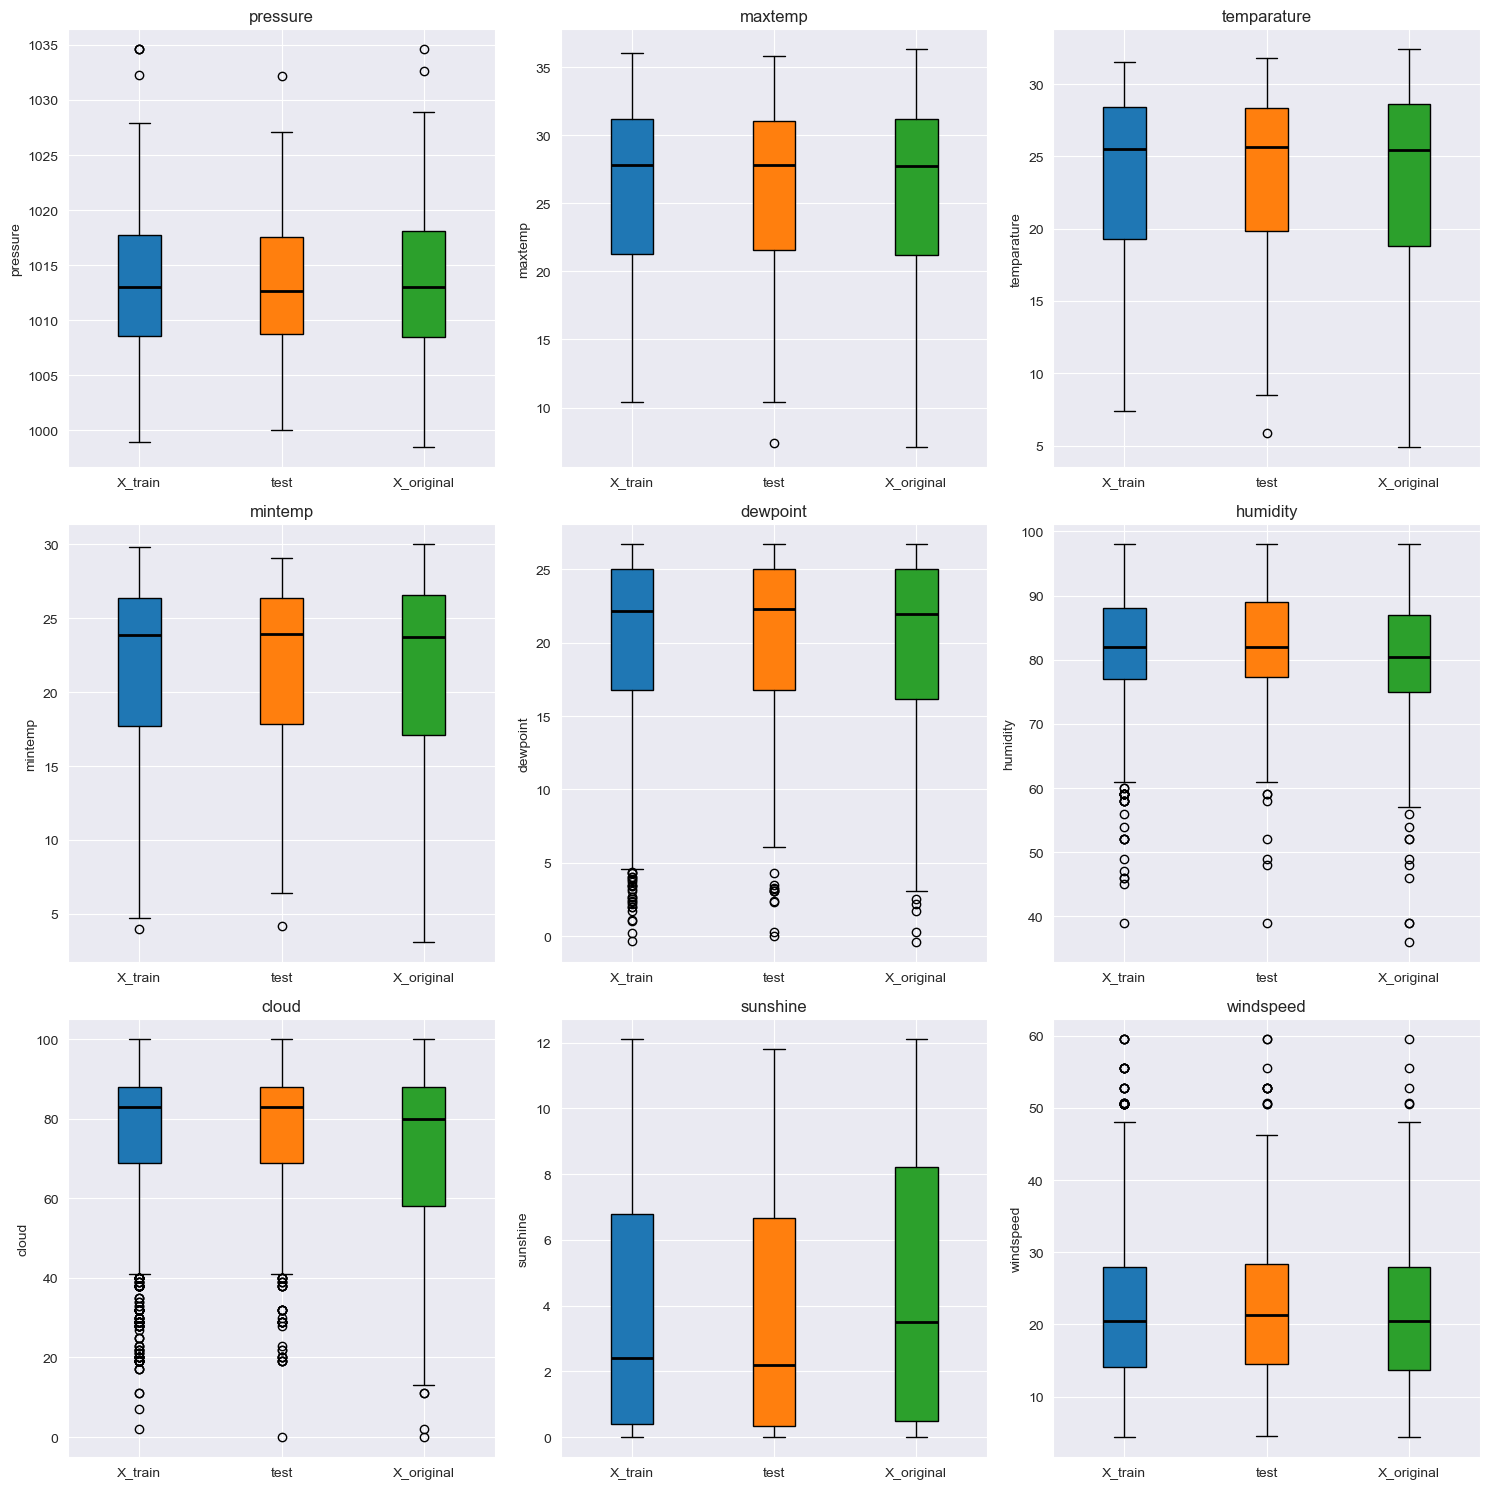

In [46]:
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

for idx, col in enumerate(cols_to_plot):
    ax = axes[idx]
    data = [X_train[col], test[col], X_original[col].dropna()]

    bp = ax.boxplot(data, patch_artist=True, tick_labels=['X_train', 'test', 'X_original'],
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)

    ax.set_title(col)
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

And for wind direction

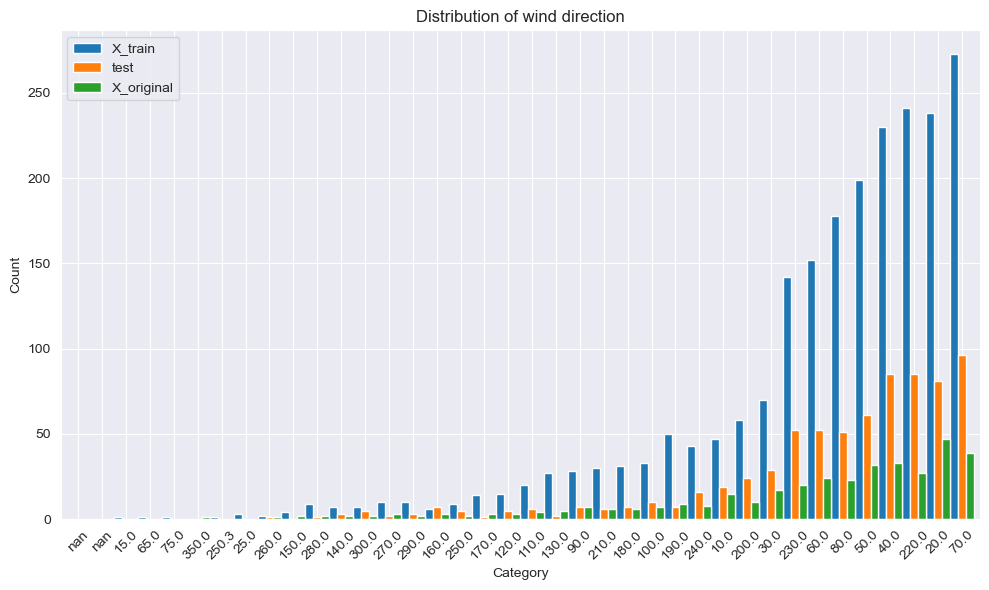

In [50]:
all_categories = set(X_train['winddirection'].unique()) \
                 | set(X_original['winddirection'].unique()) \
                 | set(test['winddirection'].unique())
all_categories = list(all_categories)

train_counts = X_train['winddirection'].value_counts().reindex(all_categories, fill_value=0)
original_counts = X_original['winddirection'].value_counts().reindex(all_categories, fill_value=0)
test_counts = test['winddirection'].value_counts().reindex(all_categories, fill_value=0)

df_counts = pd.DataFrame({
    'X_train': train_counts,
    'test': test_counts,
    'X_original': original_counts
}, index=all_categories)

df_counts['total'] = df_counts.sum(axis=1)
df_counts = df_counts.sort_values('total', ascending=True).drop('total', axis=1)

ax = df_counts.plot(kind='bar', figsize=(10, 6), width=1)
ax.set_title(f'Distribution of wind direction')
ax.set_xlabel('Category')
ax.set_ylabel('Count')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

**Observations**

1. **Temperature (maxtemp, temperature, mintemp)**
   - There are some unusual high or low values.
   - Temperatures vary with the seasons, and all datasets show similar ranges.

2. **Pressure**
   - Pressure values mostly stay within a small range (around 1000–1020 hPa).
   - There are slight differences in some datasets, but overall it's pretty stable.

3. **Humidity and Dewpoint**
   - These features have a wider spread and tend to lean towards higher values.
   - They are important for predicting rain because higher humidity and dewpoint often mean more rain.

4. **Cloud and Sunshine**
   - **Cloud**: Most days show low to moderate cloud cover, with a few days having a lot of clouds.
   - **Sunshine**: Most days receive a moderate amount of sunshine, but some days get a lot.

5. **Windspeed**
   - Windspeed values vary a lot, usually staying under 30, with some higher outliers.
   - Extreme wind speeds might be important for certain predictions.

**Overall**, humidity, dewpoint, and cloud cover seem to be key for predicting rain, while temperature and pressure help indicate seasonal trends. Managing outliers and handling skewed data may lead to better model performance. After understanding the data we can actually get season from day column so it may be useful later

*Dew point - the temperature point at which the air can hold no more water (water vapor) and is one of the factors in the heat index. It is always lower or the same as the air temperature.*

## Feature engineering

In [29]:
def get_season(day):
    month = (day % 365) // 31
    if month in [12, 1, 2]:
        return 0
    elif month in [3, 4, 5]:
        return 1
    elif month in [6, 7, 8]:
        return 2
    else:
        return 3

In [42]:
train = df_train.copy()
train['season'] = train['day'].apply(get_season)
train.drop(['id', 'day'], axis=1, inplace=True)
train.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall,season
0,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1,3
1,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1,3
2,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1,3
3,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1,3
4,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0,3


In [43]:
train['temp_range'] = train['maxtemp'] - train['mintemp']
train['temp_dew_diff'] = train['temparature'] - train['dewpoint']
train['humid_temp'] = train['humidity'] * train['temparature']
train['cloud_sun_ratio'] = train['cloud'] / (train['sunshine'] + 1)
train['wind_speed_category'] = pd.cut(train['windspeed'], bins=[0, 10, 20, 30, 50, 100], labels=[1, 2, 3, 4, 5])
train['wind_speed_category'] = train['wind_speed_category'].astype('int')

In [44]:
train

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall,season,temp_range,temp_dew_diff,humid_temp,cloud_sun_ratio,wind_speed_category
0,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1,3,1.3,1.2,1792.2,41.904762,2
1,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1,3,0.4,1.5,1605.5,91.000000,3
2,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1,3,4.8,6.8,1207.5,5.053763,2
3,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1,3,1.2,1.0,1691.0,95.000000,4
4,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0,3,6.1,8.8,956.8,9.782609,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2185,1014.6,23.2,20.6,19.1,19.9,97.0,88.0,0.1,40.0,22.1,1,3,4.1,0.7,1998.2,80.000000,3
2186,1012.4,17.2,17.3,16.3,15.3,91.0,88.0,0.0,50.0,35.3,1,3,0.9,2.0,1574.3,88.000000,4
2187,1013.3,19.0,16.3,14.3,12.6,79.0,79.0,5.0,40.0,32.9,1,3,4.7,3.7,1287.7,13.166667,4
2188,1022.3,16.4,15.2,13.8,14.7,92.0,93.0,0.1,40.0,18.0,1,3,2.6,0.5,1398.4,84.545455,2


<Axes: >

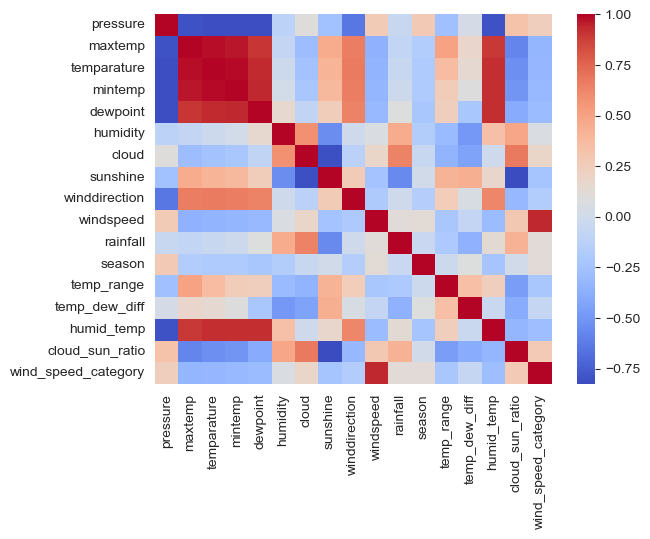

In [45]:
corr = train.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm')

### Normalization

In [47]:
X_train = train.drop('rainfall', axis=1)
Y_train = train['rainfall']

categorical_cols = ['season', 'wind_speed_category']
numeric_cols = [col for col in X_train.columns if col not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

X_train_norm = preprocessor.fit_transform(X_train)
num_features = numeric_cols
cat_features = list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols))
new_columns = num_features + cat_features
X_train_norm = pd.DataFrame(X_train_norm, columns=new_columns)
X_train_norm.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,...,cloud_sun_ratio,season_0,season_1,season_2,season_3,wind_speed_category_1,wind_speed_category_2,wind_speed_category_3,wind_speed_category_4,wind_speed_category_5
0,0.671702,-0.913809,-0.642199,-0.448815,-0.199457,0.636434,0.681269,-0.729397,-0.560901,-0.465291,...,0.195579,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1,1.043116,-1.798289,-1.350846,-1.259418,-0.956001,1.662224,0.847728,-1.032804,-0.685925,0.009629,...,1.760572,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,1.856688,-1.232222,-1.504067,-1.496667,-2.109731,-0.902250,-1.593680,1.256536,-0.435876,-0.374349,...,-0.979109,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,-0.035752,-1.462187,-1.178472,-1.041939,-0.691210,1.662224,1.069675,-1.032804,-0.560901,1.393971,...,1.888079,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,1.449902,-0.896120,-1.063556,-1.378043,-2.052990,-3.851394,-1.704654,-0.039837,-0.810950,0.302665,...,-0.828369,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [48]:
X_test = df_test.copy()
X_test['season'] = X_test['day'].apply(get_season)
X_test.drop(['id', 'day'], axis=1, inplace=True)
X_test['temp_range'] = X_test['maxtemp'] - X_test['mintemp']
X_test['temp_dew_diff'] = X_test['temparature'] - X_test['dewpoint']
X_test['humid_temp'] = X_test['humidity'] * X_test['temparature']
X_test['cloud_sun_ratio'] = X_test['cloud'] / (X_test['sunshine'] + 1)
X_test['wind_speed_category'] = pd.cut(X_test['windspeed'], bins=[0, 10, 20, 30, 50, 100], labels=[1, 2, 3, 4, 5])
X_test['wind_speed_category'] = X_test['wind_speed_category'].astype('int')

X_test_norm = preprocessor.transform(X_test)
X_test_norm = pd.DataFrame(X_test_norm, columns=new_columns)
X_test_norm.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,...,cloud_sun_ratio,season_0,season_1,season_2,season_3,wind_speed_category_1,wind_speed_category_2,wind_speed_category_3,wind_speed_category_4,wind_speed_category_5
0,1.043116,-1.568324,-1.561525,-1.872313,-1.050569,1.790447,1.291621,-1.032804,-0.685925,0.252142,...,2.015586,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,0.512525,-1.568324,-1.427456,-1.259418,-1.012742,1.918671,1.291621,-1.032804,-0.685925,1.363657,...,2.015586,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,1.821316,-2.682769,-2.595766,-2.524749,-2.185385,0.508211,1.125161,-1.032804,-0.810950,-0.495605,...,1.919956,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,1.644452,-1.019947,-1.274235,-1.378043,-2.071904,-0.902250,-1.704654,0.925547,-1.061000,2.909674,...,-0.963113,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,1.520647,-1.815979,-1.944577,-3.117873,-3.055411,-1.799815,-1.482707,1.504778,-1.061000,-0.242988,...,-0.987073,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
